In [1]:
import torch
from transformers import CLIPModel, CLIPProcessor
import matplotlib.pyplot as plt
import random
import numpy as np
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from tqdm_joblib import tqdm_joblib
import pickle
import math
from sklearn.metrics.pairwise import cosine_similarity
import itertools
import glob
import json

In [2]:
image_set = 'h&m'
text_set = 'opencharacter'

In [3]:
with open(f'../data_preparation/{image_set}/images_train.pkl', 'rb') as f:
    images = pickle.load(f)
with open(f'../data_preparation/{image_set}/pixel_values_train.pkl', 'rb') as f:
    pixel_values = torch.load(f, weights_only=False)
with open(f'../data_preparation/{text_set}/train_personas.json', 'r') as f:
    personas = json.load(f)
with open(f'../data_preparation/{text_set}/openai/train_persona_embeddings.pkl', 'rb') as f:
    openai_embeddings = pickle.load(f)
with open(f'../data_preparation/{text_set}/clip/train_persona_embeddings.pkl', 'rb') as f:
    clip_embeddings = pickle.load(f)

In [4]:
device = "cuda"
num_images = 5

In [5]:
def search_image_embeddings(text, embeddings, images, model, processor, top_k=num_images):
    # Encode the text
    text_inputs = processor(text=[text], return_tensors="pt", padding=True, truncation=True, max_length=77).to(embeddings.device)
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # Normalize embeddings (if not already)
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

    # Compute cosine similarity
    cos_sim = torch.matmul(embeddings, text_features.T).squeeze()  # shape: (num_images,)

    # Get top-k indices
    top_k = min(top_k, len(images))
    top_values, top_indices = torch.topk(cos_sim, k=top_k)

    # plt.plot(np.log(top_values.cpu().numpy()), marker='o')

    # Return list of (index, similarity)
    return [(i.item(), top_values[j].item()) for j, i in enumerate(top_indices)]

In [7]:
with open(f'../data_preparation/{image_set}/image_embeddings_fashionclip.pkl', 'rb') as f:
    image_embeddings = pickle.load(f)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

[1077, 10133, 9310, 6581, 3305]


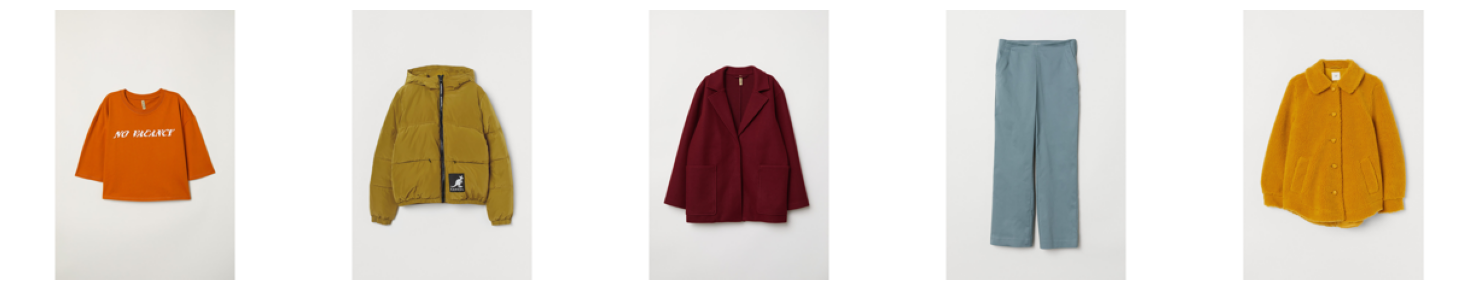

A specialist who provides strategies and resources to help children with anxiety in the learning environment


In [8]:
n = random.randint(0, len(personas) - 1)
query = personas[n]
model_fashionclip = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip")
processor_fashionclip = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
top_images_indices = [image[0] for image in search_image_embeddings(query, image_embeddings, images, model_fashionclip, processor_fashionclip)]

print(top_images_indices)
fig, axes = plt.subplots(1, len(top_images_indices), figsize=(15, 3))

for k in range(len(top_images_indices)):
    image = images[top_images_indices[k]]
    axes[k].imshow(image)
    axes[k].axis('off')

plt.tight_layout()
plt.show()
print(personas[n])

In [9]:
def sample_random_batch(openai_embeddings, clip_embeddings, personas, image_len, batch_size=num_images):
    # Randomly pick one persona embedding
    persona_idx = random.randint(0, len(personas) - 1)
    persona_openai_embedding = openai_embeddings[persona_idx]
    persona_clip_embedding = clip_embeddings[persona_idx]
    persona_text = personas[persona_idx]

    split = int(0.5 * batch_size)
    # Randomly pick `batch_size` unique image indices
    random_indices = random.sample(range(image_len), split)
    top_images_indices = [image[0] for image in search_image_embeddings(persona_text, image_embeddings, images, model_fashionclip, processor_fashionclip)]

    # top_k = 20      # How many top items to consider
    # n_sample = batch_size - split    # How many to randomly sample from the top_k
    # top_k_indices = top_images_indices[:top_k]
    # clip_indices = random.sample(top_k_indices, n_sample)
    clip_indices = top_images_indices[:(batch_size - split)]
    image_indices = random_indices + clip_indices

    return persona_openai_embedding, persona_clip_embedding, persona_text, image_indices

In [10]:
def worker_call(_):
    return sample_random_batch(openai_embeddings, clip_embeddings, personas, len(images))

n_calls = 100
num_workers = -1

with tqdm_joblib(tqdm(desc="Sampling", total=n_calls)) as progress_bar:
    results = Parallel(n_jobs=num_workers, backend="threading")(
        delayed(worker_call)(i) for i in range(n_calls)
    )

sampled_persona_openai_embeddings, sampled_persona_clip_embeddings, sampled_personas, sampled_image_indices = zip(*results)
sampled_persona_openai_embeddings = list(sampled_persona_openai_embeddings)
sampled_persona_clip_embeddings = list(sampled_persona_clip_embeddings)
sampled_personas = list(sampled_personas)
sampled_image_indices = list(sampled_image_indices)

Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

27
A professional in the field who helps the insider navigate the complexities of digital anonymity and information security
Persona index: 3037


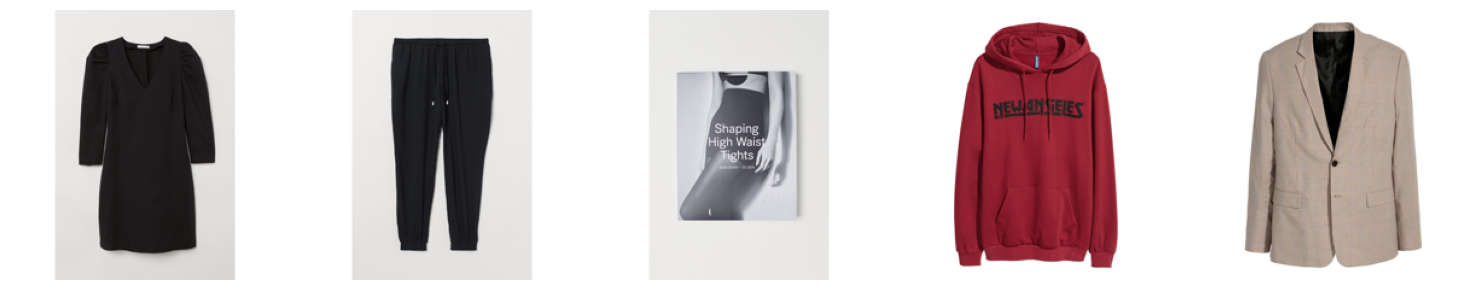

In [11]:
from random import randint

n =  randint(0, len(sampled_personas) - 1)
print(n)
print(sampled_personas[n])
print("Persona index:", personas.index(sampled_personas[n]))
images_flat = [images[i] for i in sampled_image_indices[n]]

num_images = len(images_flat)
cols = min(5, num_images)
rows = math.ceil(num_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

for k in range(num_images):
    axes[k].imshow(images_flat[k])
    axes[k].axis('off')

for k in range(num_images, len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.show()


In [12]:
with open(f"{image_set + "+" + text_set}/sampled_data.pkl", "wb") as f:
    torch.save((sampled_persona_openai_embeddings, sampled_persona_clip_embeddings, sampled_personas, sampled_image_indices), f)

In [13]:
with open(f'{image_set + "+" + text_set}/sampled_data.pkl', 'rb') as f:
    (sampled_persona_openai_embeddings, sampled_persona_clip_embeddings, sampled_personas, sampled_image_indices) = torch.load(f)

In [14]:
import tempfile
import os
from vertexai.generative_models import GenerativeModel
from vertexai.generative_models import Image as VertexImage

def check_persona_images_fit(persona_text: str, pil_images: list) -> list:
    """
    Accepts a persona text and a list of PIL images.
    Returns a list of response texts (one per image).
    """

    model = GenerativeModel("gemini-2.0-flash")


    from google.api_core.exceptions import InternalServerError
    import time
    def safe_generate(prompt, image_objs, retries=10, delay=3):
        for attempt in range(retries):
            try:
                return model.generate_content([prompt] + image_objs)
            except InternalServerError as e:
                print(f"[Retry {attempt+1}/{retries}] Gemini 500 error: {e}")
                time.sleep(delay * (2 ** attempt))  # exponential backoff
            except Exception as e:
                print(f"[Retry {attempt+1}/{retries}] Unexpected error: {e}")
                time.sleep(delay * (2 ** attempt))  # exponential backoff

        return None


    prompt = f"""
    You are evaluating how well each product in the images matches a given customer persona.

    Persona:
    {persona_text}

    You will be shown several product images.

    Please rank the images from best fit to worst fit for this persona.

    Reply ONLY with a comma-separated list of image numbers (starting at 1 for the first image) ordered from best fit to worst fit.

    For example, if image 3 fits best, then image 1, then image 2, reply:
    3,1,2

    Do NOT include any explanation or additional text.
    """
    try:
        # Save all images to temporary files, load into Image objects
        image_objs = []
        temp_files = []
        try:
            for pil_image in pil_images:
                tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
                pil_image.save(tmp.name)
                temp_files.append(tmp.name)
                image_obj = VertexImage.load_from_file(tmp.name)
                image_objs.append(image_obj)
                tmp.close()

            # Generate response with prompt + all images
            response = safe_generate(prompt, image_objs)
            # You might get a single combined response — if you want per image,
            # you could send one call per image in a loop instead.

        finally:
            # Clean up temp files
            for f in temp_files:
                try:
                    os.remove(f)
                except Exception:
                    pass

        return response.text
    except Exception as e:
        print(f"Error generating response: {e}")
        return "Error generating response"

In [15]:
from PIL import Image

def halve_image_dimensions(image: Image.Image) -> Image.Image:
    """Return a new image that is half the width and height of the original."""
    width, height = image.size
    return image.resize((width // 2, height // 2))

In [17]:
import re

def parse_ranking(text):
    return list(map(int, re.findall(r'\d+', text)))

def evaluate_pair(n):
    return check_persona_images_fit(sampled_personas[n], [images[i] for i in sampled_image_indices[n]])

num_items = len(sampled_image_indices)

for n, batch in enumerate(tqdm(itertools.batched(range(num_items), 2000), desc="Evaluating batches")):
    # Number of tasks
    # Run with progress bar and error handling
    if os.path.exists(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_scores{n}.pkl'):
        print(f"Skipping batch {n} as scores already exist.")
        continue 

    with tqdm_joblib(desc="Scoring persona-image pairs", total=len(batch)):
        scores = Parallel(n_jobs=8, backend="threading")(
            delayed(evaluate_pair)(n) for n in batch
        )

    # Build filtered lists
    clean_scores = []
    clean_image_indices = []
    clean_personas = []
    clean_openai_embeddings = []
    clean_clip_embeddings = []

    for score, sampled_persona, sampled_image_index, sampled_openai_embedding, sampled_clip_embedding in zip(scores, sampled_personas, sampled_image_indices, sampled_persona_openai_embeddings, sampled_persona_clip_embeddings):
        ranking = parse_ranking(score)
        if len(ranking) == num_images:
            clean_scores.append(ranking)
            clean_image_indices.append(sampled_image_index)
            clean_personas.append(sampled_persona)
            clean_openai_embeddings.append(sampled_openai_embedding)
            clean_clip_embeddings.append(sampled_clip_embedding)

    print(f"Kept {len(clean_scores)} out of {len(scores)} responses.")

    with open(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_scores{n}.pkl', 'wb') as f:
        pickle.dump(clean_scores, f)
    with open(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_image_indices{n}.pkl', 'wb') as f:
        torch.save(clean_image_indices, f)
    with open(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_personas{n}.pkl', 'wb') as f:
        pickle.dump(clean_personas, f)
    with open(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_openai_embeddings{n}.pkl', 'wb') as f:
        torch.save(clean_openai_embeddings, f)
    with open(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_clip_embeddings{n}.pkl', 'wb') as f:
        torch.save(clean_clip_embeddings, f)

Evaluating batches: 0it [00:00, ?it/s]

Scoring persona-image pairs:   0%|          | 0/100 [00:00<?, ?it/s]

Kept 98 out of 100 responses.


In [ ]:
# for i in range(25):
#     with open(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_personas{i}.pkl', 'rb') as f:
#         sampled_personas = pickle.load(f)

#     persona_indices = []

#     for persona in sampled_personas:
#         persona_indices.append(personas.index(persona))

#     clean_clip_embeddings = []
#     for ind in persona_indices:
#         clean_clip_embeddings.append(clip_embeddings[ind])

#     with open(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_clip_embeddings{i}.pkl', 'wb') as f:
#         torch.save(clean_clip_embeddings, f)

In [ ]:
# Helper function to load a pickle file
def load_pickle(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

def load_torch(filename):
    with open(filename, 'rb') as f:
        return torch.load(f)

# Gather all files matching the patterns
openai_embedding_files = sorted(glob.glob(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_openai_embeddings*'))
clip_embedding_files = sorted(glob.glob(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_clip_embeddings*'))
image_index_files = sorted(glob.glob(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_image_indices*'))
persona_files = sorted(glob.glob(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_personas*'))
score_files = sorted(glob.glob(f'{image_set + "+" + text_set}/distill_drift_fashionclip_data/drift_fashionclip_scores*'))

# Load and concatenate all files
def combine_pickles(file_list):
    combined = []
    for file in file_list:
        data = load_pickle(file)
        combined.extend(data)  # Use .extend() if data is a list or similar
    return combined

def combine_torch(file_list):
    combined = []
    for file in file_list:
        data = load_torch(file)
        combined.extend(data)  # Use .extend() if data is a list or similar
    return combined

# Combine the data
openai_embeddings = combine_torch(openai_embedding_files)
clip_embeddings = combine_torch(clip_embedding_files)
image_indices = combine_torch(image_index_files)
personas = combine_pickles(persona_files)
scores = combine_pickles(score_files)

In [ ]:
print("dumping scores")
with open(f'{image_set + "+" + text_set}/openai/drift_data/drift_clean_scores0.pkl', 'wb') as f:
    pickle.dump(scores, f)
with open(f'{image_set + "+" + text_set}/clip/drift_data/drift_clean_scores0.pkl', 'wb') as f:
    pickle.dump(scores, f)

print("dumping personas")
with open(f'{image_set + "+" + text_set}/openai/drift_data/drift_clean_personas0.pkl', 'wb') as f:
    pickle.dump(personas, f)
with open(f'{image_set + "+" + text_set}/clip/drift_data/drift_clean_personas0.pkl', 'wb') as f:
    pickle.dump(personas, f)

print("dumping image indices")
with open(f'{image_set + "+" + text_set}/openai/drift_data/drift_clean_image_indices0.pkl', 'wb') as f:
    torch.save(image_indices, f)
with open(f'{image_set + "+" + text_set}/clip/drift_data/drift_clean_image_indices0.pkl', 'wb') as f:
    torch.save(image_indices, f)

print("dumping openai embeddings")
with open(f'{image_set + "+" + text_set}/openai/drift_data/drift_clean_openai_embeddings0.pkl', 'wb') as f:
    torch.save(openai_embeddings, f)

print("dumping clip embeddings")
with open(f'{image_set + "+" + text_set}/clip/drift_data/drift_clean_clip_embeddings0.pkl', 'wb') as f:
    torch.save(clip_embeddings, f)

dumping scores
dumping personas
dumping image indices
dumping openai embeddings
dumping clip embeddings


In [ ]:
embedding_mode = "clip"

In [ ]:
import pickle
import torch

# Load scores (from pickle)
with open(f'{image_set + "+" + text_set}/{embedding_mode}/drift_data/drift_clean_scores0.pkl', 'rb') as f:
    scores = pickle.load(f)

# Load personas (from pickle)
with open(f'{image_set + "+" + text_set}/{embedding_mode}/drift_data/drift_clean_personas0.pkl', 'rb') as f:
    personas = pickle.load(f)

# Load image indices (from torch)
with open(f'{image_set + "+" + text_set}/{embedding_mode}/drift_data/drift_clean_image_indices0.pkl', 'rb') as f:
    image_indices = torch.load(f)

# Load embeddings (from torch)
with open(f'{image_set + "+" + text_set}/{embedding_mode}/drift_data/drift_clean_{embedding_mode}_embeddings0.pkl', 'rb') as f:
    embeddings = torch.load(f)


A wealthy businessman who views the football club as a valuable investment and expects positive media exposure for financial gain


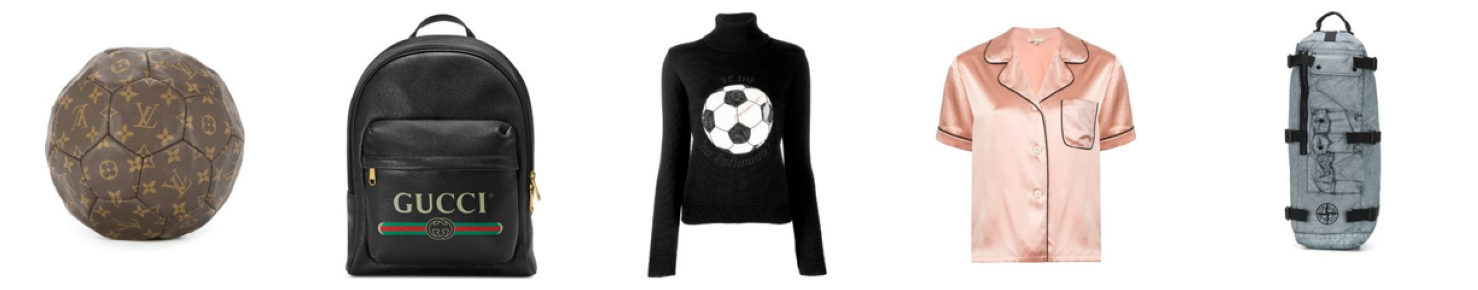

In [ ]:
from random import randint

n = randint(0, len(scores) - 1)
print(personas[n])

ordered_indices = [image_indices[n][i - 1] for i in scores[n]] 

images_flat = [images[i] for i in ordered_indices]

num_images = len(images_flat)
cols = min(5, num_images)
rows = math.ceil(num_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

for k in range(num_images):
    axes[k].imshow(images_flat[k])
    axes[k].axis('off')

for k in range(num_images, len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.show()
